# **Chapter 4 - Homework**

**Setting up the data:**

In [232]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

from tqdm.auto import tqdm

In [165]:
SEED = 1999

In [166]:
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

Pandas: 2.3.1
Numpy: 2.3.1


In [167]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [168]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [169]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [170]:
cat_cols = list(df.select_dtypes(include=['object']).columns)
num_cols = list(df.select_dtypes(include=['number']).columns)
cat_cols, num_cols

(['lead_source', 'industry', 'employment_status', 'location'],
 ['number_of_courses_viewed',
  'annual_income',
  'interaction_count',
  'lead_score',
  'converted'])

In [171]:
num_cols = [c for c in num_cols if c != "converted"]
num_cols

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [172]:
df[cat_cols] = df[cat_cols].fillna("NA")

In [173]:
df[num_cols] = df[num_cols].fillna(0.0)

In [174]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [175]:
n = 0.2
df_full_train, df_test = train_test_split(df, test_size=n, random_state=SEED)
df_train, df_val = train_test_split(df_full_train, test_size=n/(1-n), random_state=SEED)

In [176]:
df_train.shape, df_val.shape, df_test.shape

((876, 9), (293, 9), (293, 9))

## Question 1 - ROC AUC Feature Importance
**number_of_courses_viewed** gives the highest AUC score

In [177]:
scores = {}
for c in num_cols:
    scores[c] = roc_auc_score(df_train["converted"], df_train[c])

In [178]:
scores

{'number_of_courses_viewed': 0.7713624338624339,
 'annual_income': 0.5468805114638449,
 'interaction_count': 0.7385774911816579,
 'lead_score': 0.5992724867724868}

## Question 2 - Training the Model
The initial AUC score was rougly 0.82. After scaling the training features, we got an AUC score of **0.92**

In [179]:
dv = DictVectorizer(sparse=False)

In [180]:
train_dicts = df_train[num_cols + cat_cols].to_dict(orient='records')
val_dicts = df_val[num_cols + cat_cols].to_dict(orient='records')
test_dicts = df_test[num_cols + cat_cols].to_dict(orient='records')
full_train_dicts = df_full_train[num_cols + cat_cols].to_dict(orient='records')

In [181]:
dv.fit(train_dicts)

,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,False
,sort,True


In [182]:
X_train = dv.transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)
X_full_train = dv.transform(full_train_dicts)

In [183]:
y_full_train = df_full_train["converted"].values
y_train = df_train["converted"].values
y_val = df_val["converted"].values
y_test = df_test["converted"].values

In [184]:
del df_full_train["converted"]
del df_train["converted"]
del df_val["converted"]
del df_test["converted"]

In [185]:
model = LogisticRegression(solver='lbfgs', C=1.0, max_iter=10000)

In [186]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [187]:
y_pred = model.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8968388512165935

In [188]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

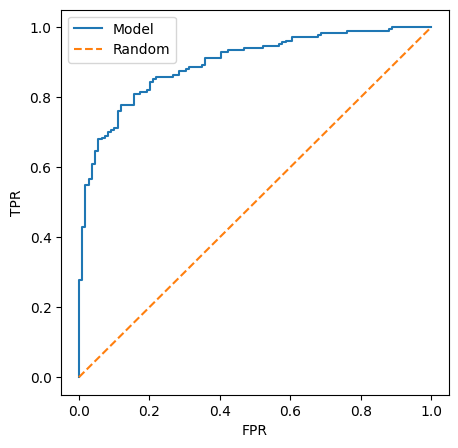

In [189]:

plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()



In [190]:
#@ TRAINING LOGISTIC REGRESSION MODEL:
columns = cat_cols + num_cols

train_dicts = df_train[columns].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

model = LogisticRegression(solver='lbfgs', C=1.0, max_iter=10000)
model.fit(X_train, y_train)

val_dicts = df_val[columns].to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = model.predict_proba(X_val)[:, 1]

In [191]:
roc_auc_score(y_val, y_pred)

0.8968388512165935

In [192]:
# Using a StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_val_s = scaler.transform(X_val)

model = LogisticRegression(solver='lbfgs', C=1.0, max_iter=10000)
model.fit(X_train_s, y_train)

y_pred_s = model.predict_proba(X_val_s)[:, 1]

In [193]:
normal_score = roc_auc_score(y_val, y_pred)
scaled_score = roc_auc_score(y_val, y_pred_s)
round(normal_score, 3), round(scaled_score, 3)

(0.897, 0.897)

In [194]:
df_ann_income = df_train.annual_income
X_train_ann_income = X_train[:, 0]
X_train_s_ann_income = X_train_s[:, 0]

X_train_ann_income[0:5]

array([59090., 50327., 50631., 77835., 47262.])

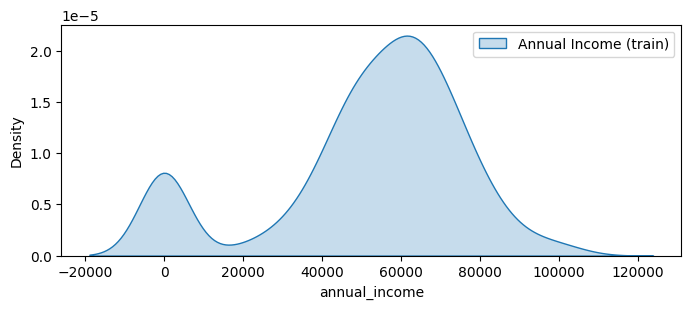

In [195]:


plt.figure(figsize=(8, 3))
sns.kdeplot(df_ann_income, label='Annual Income (train)', fill=True)
#sns.kdeplot(X_train_ann_income, label='Annual Income (train, unscaled)', fill=True)
#sns.kdeplot(X_train_s_ann_income, label='Annual Income (train, scaled)', fill=True)
plt.legend()

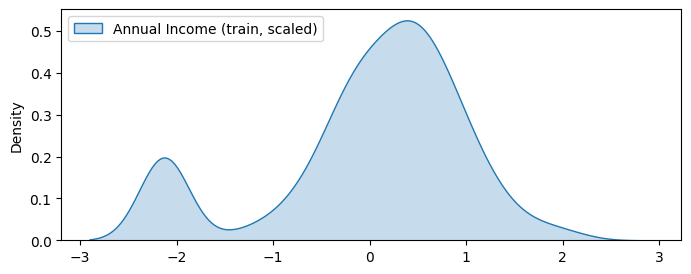

In [196]:


plt.figure(figsize=(8, 3))
#sns.kdeplot(df_ann_income, label='Annual Income (train)', fill=True)
#sns.kdeplot(X_train_ann_income, label='Annual Income (train, unscaled)', fill=True)
sns.kdeplot(X_train_s_ann_income, label='Annual Income (train, scaled)', fill=True)
plt.legend()

## **Question 3 - Precision and Recall**
Varing the SEED, we get an overlap somewhere between 0.518 and 0.58 ish. So the answer should be **0.545**

In [197]:
for i in range(20):
    print(f"{y_val[i]}  => {round(y_pred[i], 3)}  => {round(y_pred_s[i], 3)}")

1  => 0.829  => 0.846
1  => 0.932  => 0.946
1  => 0.954  => 0.961
1  => 0.991  => 0.994
1  => 0.841  => 0.858
1  => 0.782  => 0.821
1  => 0.983  => 0.983
1  => 0.948  => 0.946
0  => 0.004  => 0.002
1  => 0.714  => 0.745
1  => 0.965  => 0.971
1  => 1.0  => 1.0
1  => 0.992  => 0.993
0  => 0.666  => 0.717
1  => 0.262  => 0.236
0  => 0.226  => 0.226
0  => 0.353  => 0.308
1  => 0.957  => 0.959
0  => 0.51  => 0.49
1  => 0.993  => 0.994


In [198]:
thresholds = np.linspace(0.0, 1.0, num=1001)

thresholds

array([0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ], shape=(1001,))

In [216]:
actual_positive = y_val == 1
actual_negative = y_val == 0

y_pred = model.predict_proba(X_val_s)[:, 1]


scores_df = pd.DataFrame(columns=["threshold", "tp", "tn", "fp", "fn"])

for t in thresholds:
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (actual_positive & predict_positive).sum()
    tn = (actual_negative & predict_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores_df.loc[len(scores_df)] = [t, tp, tn, fp, fn]
scores_df

,threshold,tp,tn,fp,fn
0,0.000,184.0,0.0,109.0,0.0
1,0.001,184.0,0.0,109.0,0.0
2,0.002,184.0,2.0,107.0,0.0
3,0.003,184.0,3.0,106.0,0.0
4,0.004,184.0,3.0,106.0,0.0
...,...,...,...,...,...
996,0.996,35.0,109.0,0.0,149.0
997,0.997,31.0,109.0,0.0,153.0
998,0.998,28.0,109.0,0.0,156.0
999,0.999,19.0,109.0,0.0,165.0


In [200]:
def tpr_fpr_dataframe(y_val, y_pred):
    thresholds = np.linspace(0, 1, 1001)

    scores = []


    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0) 

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()


        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        diff = abs(precision - recall)

        scores.append((t, tp, fp, tn, fn, precision, recall, diff))
    columns = ["threshold", "tp", "fp", "tn", "fn", "precision", "recall", "diff"]
    return pd.DataFrame(scores, columns=columns)

In [217]:
scores_df = tpr_fpr_dataframe(y_val, y_pred)
scores_df.loc[0:100:10]

/tmp/ipykernel_2276/2982749886.py:20: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


,threshold,tp,fp,tn,fn,precision,recall,diff
0,0.00,184,109,0,0,0.627986,1.000000,0.372014
10,0.01,184,103,6,0,0.641115,1.000000,0.358885
20,0.02,182,96,13,2,0.654676,0.989130,0.334454
30,0.03,182,91,18,2,0.666667,0.989130,0.322464
40,0.04,182,86,23,2,0.679104,0.989130,0.310026
50,0.05,182,85,24,2,0.681648,0.989130,0.307482
60,0.06,182,83,26,2,0.686792,0.989130,0.302338
70,0.07,182,83,26,2,0.686792,0.989130,0.302338
80,0.08,181,79,30,3,0.696154,0.983696,0.287542
90,0.09,181,79,30,3,0.696154,0.983696,0.287542


In [218]:
#0.0045559635522914865

scores_df[scores_df["diff"] == scores_df["diff"].min()]

,threshold,tp,fp,tn,fn,precision,recall,diff
480,0.480,157,27,82,27,0.853261,0.853261,0.0
481,0.481,157,27,82,27,0.853261,0.853261,0.0
482,0.482,157,27,82,27,0.853261,0.853261,0.0
483,0.483,157,27,82,27,0.853261,0.853261,0.0
484,0.484,157,27,82,27,0.853261,0.853261,0.0
485,0.485,157,27,82,27,0.853261,0.853261,0.0
486,0.486,157,27,82,27,0.853261,0.853261,0.0
487,0.487,157,27,82,27,0.853261,0.853261,0.0
488,0.488,157,27,82,27,0.853261,0.853261,0.0


<Axes: xlabel='threshold', ylabel='precision'>

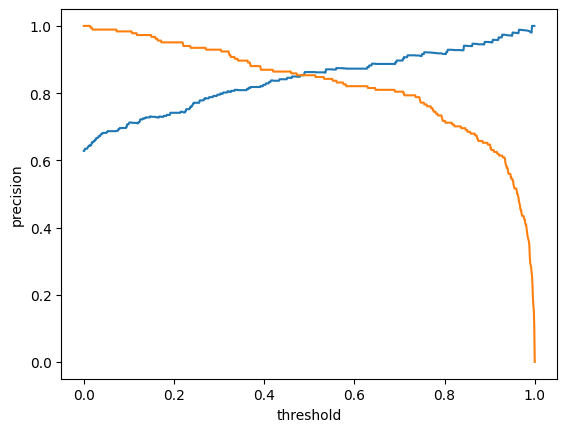

In [219]:
sns.lineplot(x=scores_df.threshold, y=scores_df.precision)
sns.lineplot(x=scores_df.threshold, y=scores_df.recall)


In [220]:
def tpr_fpr_dataframe2(y_val, y_pred):
    thresholds = np.linspace(0, 1, 101)

    scores = []


    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0) 

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        scores.append((t, tp, fp, tn, fn, tpr, fpr))
    columns = ["threshold", "tp", "fp", "tn", "fn", "tpr", "fpr"]
    return pd.DataFrame(scores, columns=columns)

In [205]:
something = tpr_fpr_dataframe(y_val, y_pred_s)

/tmp/ipykernel_2276/2982749886.py:20: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


## **Question 4 - F1 Score**

$$F_1 = 2\cdot\frac{P \cdot R}{P + R}$$

It looks like we are getting a maximum F1 score around **0.32**

In [221]:
scores_df.head()

,threshold,tp,fp,tn,fn,precision,recall,diff
0,0.000,184,109,0,0,0.627986,1.0,0.372014
1,0.001,184,109,0,0,0.627986,1.0,0.372014
2,0.002,184,107,2,0,0.632302,1.0,0.367698
3,0.003,184,106,3,0,0.634483,1.0,0.365517
4,0.004,184,106,3,0,0.634483,1.0,0.365517


In [226]:
scores_df["F1"] = 2*(scores_df["precision"] * scores_df["recall"])/(scores_df["precision"] + scores_df["recall"])
scores_df[0:1000:100]

,threshold,tp,fp,tn,fn,precision,recall,diff,F1
0,0.0,184,109,0,0,0.627986,1.000000,0.372014,0.771488
100,0.1,181,74,35,3,0.709804,0.983696,0.273892,0.824601
200,0.2,175,61,48,9,0.741525,0.951087,0.209562,0.833333
300,0.3,171,44,65,13,0.795349,0.929348,0.133999,0.857143
400,0.4,160,34,75,24,0.824742,0.869565,0.044823,0.846561
500,0.5,157,25,84,27,0.862637,0.853261,0.009376,0.857923
600,0.6,151,22,87,33,0.872832,0.820652,0.052180,0.845938
700,0.7,148,17,92,36,0.896970,0.804348,0.092622,0.848138
800,0.8,132,12,97,52,0.916667,0.717391,0.199275,0.804878
900,0.9,119,6,103,65,0.952000,0.646739,0.305261,0.770227


In [227]:
scores_df[scores_df["F1"] == scores_df["F1"].max()]

,threshold,tp,fp,tn,fn,precision,recall,diff,F1
319,0.319,170,41,68,14,0.805687,0.923913,0.118226,0.860759
320,0.320,170,41,68,14,0.805687,0.923913,0.118226,0.860759
321,0.321,170,41,68,14,0.805687,0.923913,0.118226,0.860759


In [209]:
scores_df2 = tpr_fpr_dataframe(y_val, y_pred)
scores_df2.head()

,threshold,tp,fp,tn,fn,precision,recall,diff
0,0.000,184,109,0,0,0.627986,1.0,0.372014
1,0.001,184,109,0,0,0.627986,1.0,0.372014
2,0.002,184,109,0,0,0.627986,1.0,0.372014
3,0.003,184,109,0,0,0.627986,1.0,0.372014
4,0.004,184,109,0,0,0.627986,1.0,0.372014


In [210]:
scores_df2["F1"] = 2*(scores_df2["precision"] * scores_df2["recall"])/(scores_df2["precision"] + scores_df2["recall"])
scores_df2.tail()

,threshold,tp,fp,tn,fn,precision,recall,diff,F1
996,0.996,184,107,2,0,0.632302,1.000000,0.367698,0.774737
997,0.997,184,107,2,0,0.632302,1.000000,0.367698,0.774737
998,0.998,184,107,2,0,0.632302,1.000000,0.367698,0.774737
999,0.999,184,107,2,0,0.632302,1.000000,0.367698,0.774737
1000,1.000,155,95,14,29,0.620000,0.842391,0.222391,0.714286


In [211]:
scores_df2[scores_df2["F1"] == scores_df2["F1"].max()]

,threshold,tp,fp,tn,fn,precision,recall,diff,F1
990,0.990,184,107,2,0,0.632302,1.0,0.367698,0.774737
991,0.991,184,107,2,0,0.632302,1.0,0.367698,0.774737
992,0.992,184,107,2,0,0.632302,1.0,0.367698,0.774737
993,0.993,184,107,2,0,0.632302,1.0,0.367698,0.774737
994,0.994,184,107,2,0,0.632302,1.0,0.367698,0.774737
995,0.995,184,107,2,0,0.632302,1.0,0.367698,0.774737
996,0.996,184,107,2,0,0.632302,1.0,0.367698,0.774737
997,0.997,184,107,2,0,0.632302,1.0,0.367698,0.774737
998,0.998,184,107,2,0,0.632302,1.0,0.367698,0.774737
999,0.999,184,107,2,0,0.632302,1.0,0.367698,0.774737


## **Question 5 - 5-Fold CV**
Different parameters seem to give answers in the range of **0.06**

In [231]:
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [ ]:
def train(df, y_train, categorical, numerical, C=1.0):
    dicts = df[categorical + numerical].to_dict(orient="records")
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    X_val = dv.transform()
    model = LogisticRegression(solver="liblinear", max_iter=1000, C=C)
    model.fit(X_train, y_train)

    return dv, model, X_train, X_val

In [263]:
def train_kfold(df_full_train, target, n_splits=5, random_state=1, Cs=[1], max_iter=1000, solver="liblinear"):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    auc_scores = pd.DataFrame(columns=["n_fold", "C", "auc"])
    for C in tqdm(Cs):

        
        n = 0
        for df_train_idx, df_val_idx in kfold.split(df_full_train):
            
            df_train = df_full_train.iloc[df_train_idx]
            df_val = df_full_train.iloc[df_val_idx]

            
            y_train = df_train[target].values
            y_val = df_val[target].values

            del df_train[target]
            del df_val[target]

            dicts_train = df_train[cat_cols + num_cols].to_dict(orient="records")
            dicts_val = df_val[cat_cols + num_cols].to_dict(orient="records")


            dv = DictVectorizer(sparse=False)
            X_train = dv.fit_transform(dicts_train)
            X_val = dv.transform(dicts_val)

            model = LogisticRegression(solver=solver, C=C, max_iter=max_iter)

            model.fit(X_train, y_train)

            y_pred = model.predict_proba(X_val)[:, 1]

            score = roc_auc_score(y_val, y_pred)

            auc_scores.loc[len(auc_scores)] = [n, C, score]

            n += 1
    
    return auc_scores

In [275]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=SEED)
df_full_train.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
1223,organic_search,retail,1,63548.0,NA,europe,4,0.81,1
1369,paid_ads,manufacturing,2,72572.0,self_employed,south_america,2,0.17,0
699,referral,education,2,62165.0,student,asia,3,0.04,1
575,paid_ads,finance,3,43063.0,unemployed,middle_east,4,0.66,1
855,referral,manufacturing,2,54480.0,employed,europe,1,0.94,1


In [278]:

kfold_scores = train_kfold(df_full_train, "converted", n_splits=25, solver="lbfgs", max_iter=10000, random_state=SEED)
print(f"Standard Deviation: {round(kfold_scores.auc.std(), 4)}")

  0%|          | 0/1 [00:00<?, ?it/s]

Standard Deviation: 0.0437


In [269]:
kfold_scores.head()

,n_fold,C,auc
0,0.0,1.0,0.880000
1,1.0,1.0,0.755435
2,2.0,1.0,0.737838
3,3.0,1.0,0.843137
4,4.0,1.0,0.771493


## **Question 6 - Hyperparameter Tuning**
A C value of **0.001** gives the highest mean AUC score

In [280]:
kfold_scores = train_kfold(df_full_train, "converted", random_state=SEED, Cs=[0.000001, 0.001, 1])
kfold_scores

  0%|          | 0/3 [00:00<?, ?it/s]

,n_fold,C,auc
0,0.0,0.000001,0.578096
1,1.0,0.000001,0.550551
2,2.0,0.000001,0.521021
3,3.0,0.000001,0.552712
4,4.0,0.000001,0.557112
5,0.0,0.001000,0.825739
6,1.0,0.001000,0.853859
7,2.0,0.001000,0.899230
8,3.0,0.001000,0.868687
9,4.0,0.001000,0.867590


In [286]:
kfold_scores.groupby("C").auc.mean()

C
0.000001    0.551898
0.001000    0.863021
1.000000    0.822132
Name: auc, dtype: float64